In [1]:
# pip install opendatasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import opendatasets as od

In [ ]:
dataset_url = "https://www.kaggle.com/datasets/theodoragilmore/metro-interstate-traffic-volume"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle username:Your Kaggle username:Your Kaggle username:

In [ ]:
df = pd.read_csv(
    "metro-interstate-traffic-volume/Metro_Interstate_Traffic_Volume_modified.csv"
)

df.head()

,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume
0,10/2/12 9:00,288.28,0.0,0.0,40.0,0.0,2.30,0.0,NaN,Clouds,scattered clouds,Weekday,5545.0
1,10/2/12 10:00,289.36,0.0,0.0,75.0,0.0,7.45,0.0,NaN,Clouds,broken clouds,Weekday,4516.0
2,10/2/12 11:00,289.58,0.0,0.0,90.0,0.0,5.68,0.0,NaN,Clouds,overcast clouds,Weekday,NaN
3,10/2/12 12:00,290.13,0.0,0.0,90.0,0.0,1.93,0.0,NaN,Clouds,overcast clouds,Weekday,5026.0
4,10/2/12 13:00,NaN,0.0,0.0,75.0,0.0,3.56,0.0,NaN,Clouds,broken clouds,Weekday,4918.0


In [ ]:
print("First 5 Rows")
print(df.head())

print("\nDataset Diagnostic Info")
df.info()

print("\nColumn Names")
print(df.columns)

print("\nMissing Values Per Column")
print(df.isnull().sum())

print("\nDuplicate Rows (Total Count)")
print(df.duplicated().sum())

First 5 Rows
       date_time    temp  rain_1h  snow_1h  clouds_all  fog_mm  wind_speed_ms  \
0   10/2/12 9:00  288.28      0.0      0.0        40.0     0.0           2.30   
1  10/2/12 10:00  289.36      0.0      0.0        75.0     0.0           7.45   
2  10/2/12 11:00  289.58      0.0      0.0        90.0     0.0           5.68   
3  10/2/12 12:00  290.13      0.0      0.0        90.0     0.0           1.93   
4  10/2/12 13:00     NaN      0.0      0.0        75.0     0.0           3.56   

   flood_mm holiday weather_main weather_description day_type  traffic_volume  
0       0.0     NaN       Clouds    scattered clouds  Weekday          5545.0  
1       0.0     NaN       Clouds       broken clouds  Weekday          4516.0  
2       0.0     NaN       Clouds     overcast clouds  Weekday             NaN  
3       0.0     NaN       Clouds     overcast clouds  Weekday          5026.0  
4       0.0     NaN       Clouds       broken clouds  Weekday          4918.0  

Dataset Diagnostic 

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['is_weekend'] = df['date_time'].dt.dayofweek >= 5

In [ ]:
df['temp_celsius'] = df['temp'] - 273

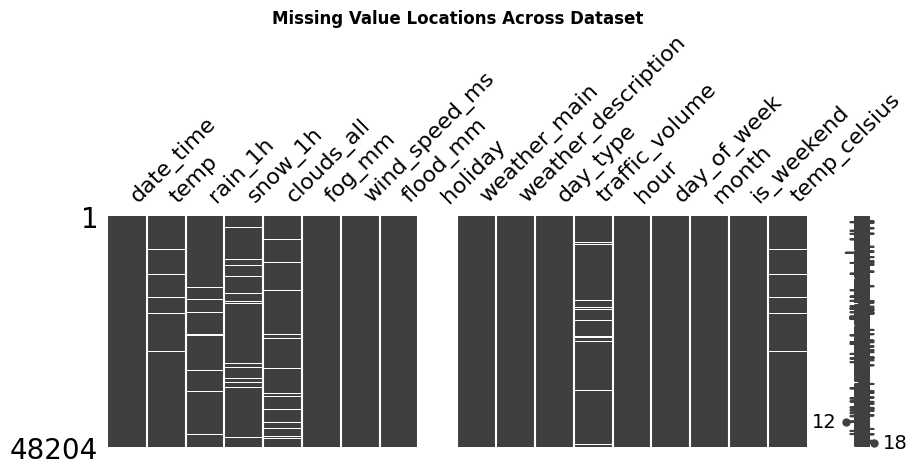

In [ ]:
msno.matrix(df, figsize=(10,3))
plt.title(
    'Missing Value Locations Across Dataset',
    fontsize=12,
    fontweight='bold'
)
plt.show()

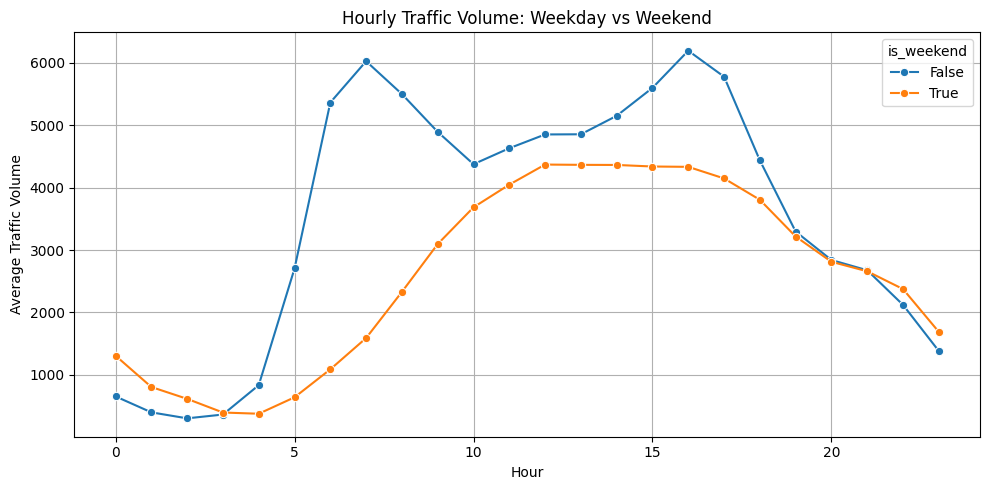

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x='hour',
    y='traffic_volume',
    hue='is_weekend',
    marker='o',
    errorbar=None
)

plt.title('Hourly Traffic Volume: Weekday vs Weekend')
plt.xlabel('Hour')
plt.ylabel('Average Traffic Volume')

plt.grid(True)
plt.tight_layout()
plt.show()

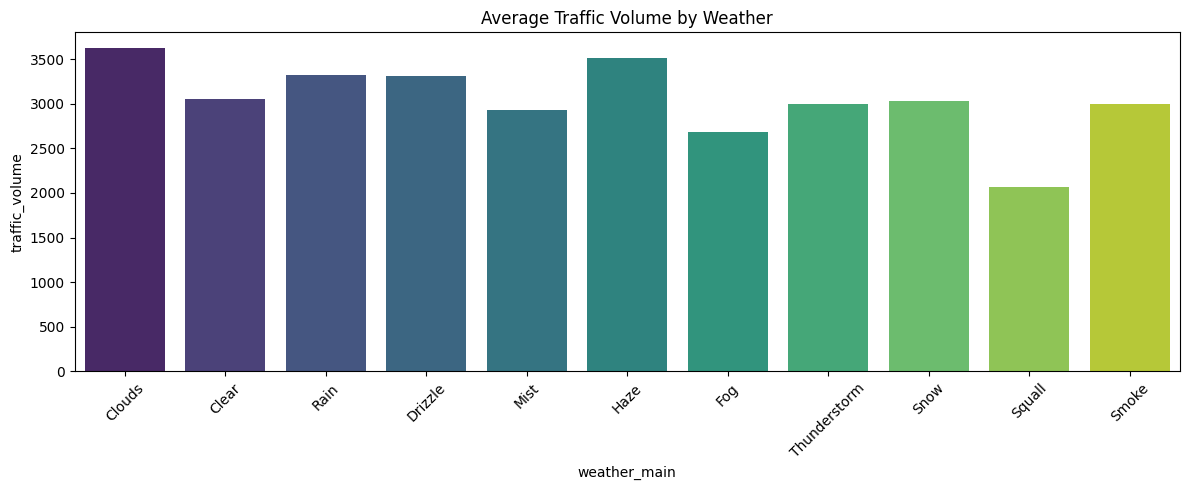

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x='weather_main',
    y='traffic_volume',
    hue='weather_main',
    palette='viridis',
    legend=False,
    errorbar=None
)

plt.title('Average Traffic Volume by Weather')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

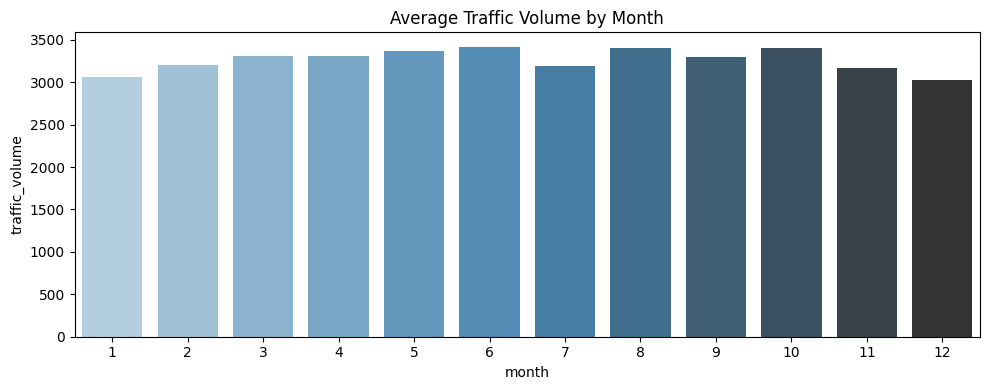

In [ ]:
plt.figure(figsize=(10,4))

sns.barplot(
    data=df,
    x='month',
    y='traffic_volume',
    hue='month',
    palette='Blues_d',
    legend=False,
    errorbar=None
)

plt.title('Average Traffic Volume by Month')

plt.tight_layout()
plt.show()

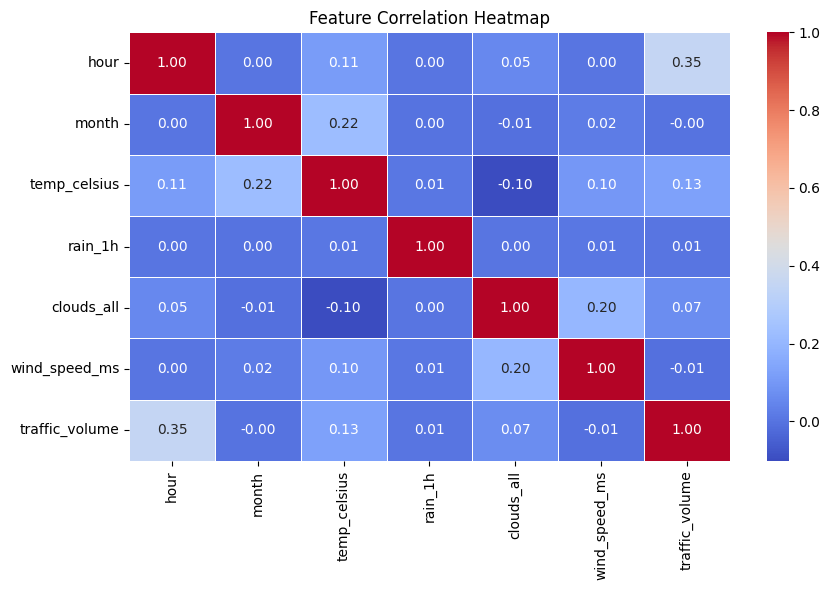

In [ ]:
numeric_cols = [
    'hour',
    'month',
    'temp_celsius',
    'rain_1h',
    'clouds_all',
    'wind_speed_ms',
    'traffic_volume'
]

plt.figure(figsize=(9,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date_time            48204 non-null  datetime64[ns]
 1   temp                 45794 non-null  float64       
 2   rain_1h              45792 non-null  float64       
 3   snow_1h              45793 non-null  float64       
 4   clouds_all           45794 non-null  float64       
 5   fog_mm               48204 non-null  float64       
 6   wind_speed_ms        48204 non-null  float64       
 7   flood_mm             48202 non-null  float64       
 8   holiday              61 non-null     object        
 9   weather_main         48204 non-null  object        
 10  weather_description  48204 non-null  object        
 11  day_type             48204 non-null  object        
 12  traffic_volume       45794 non-null  float64       
 13  hour                 48204 non-

,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,traffic_volume,hour,month,temp_celsius
count,48204,45794.000000,45792.000000,45793.000000,45794.000000,48204.000000,48204.000000,48202.000000,45794.000000,48204.000000,48204.000000,45794.000000
mean,2016-01-05 10:46:16.773711616,281.219070,0.345503,0.000230,49.406931,8.568209,5.396802,0.785051,3261.366991,11.398162,6.506037,8.219070
min,2012-10-02 09:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,-273.000000
25%,2014-02-06 11:45:00,272.180000,0.000000,0.000000,1.000000,0.000000,2.820000,0.000000,1195.000000,5.000000,4.000000,-0.820000
50%,2016-06-11 03:30:00,282.480000,0.000000,0.000000,64.000000,0.000000,5.050000,0.000000,3380.000000,11.000000,7.000000,9.480000
75%,2017-08-11 06:00:00,291.830000,0.000000,0.000000,90.000000,0.000000,7.040000,0.000000,4936.000000,17.000000,9.000000,18.830000
max,2018-09-30 23:00:00,310.070000,9831.300000,0.510000,100.000000,499.260000,24.980000,407.930000,7280.000000,23.000000,12.000000,37.070000
std,NaN,13.378092,45.953150,0.008367,39.021861,42.113011,3.548947,8.152681,1987.139170,6.940238,3.400221,13.378092


In [ ]:
df[["rain_1h","snow_1h","flood_mm"]].describe()

,rain_1h,snow_1h,flood_mm
count,45792.000000,45793.000000,48202.000000
mean,0.345503,0.000230,0.785051
std,45.953150,0.008367,8.152681
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,9831.300000,0.510000,407.930000


In [ ]:
df["holiday"] = df["holiday"].fillna("None")

df["rain_1h"] = df["rain_1h"].fillna(0)

df["snow_1h"] = df["snow_1h"].fillna(0)

df["flood_mm"] = df["flood_mm"].fillna(0)

df["temp"] = df["temp"].fillna(df["temp"].median())

df["clouds_all"] = df["clouds_all"].fillna(df["clouds_all"].median())

df = df.dropna(subset=["traffic_volume"])

In [ ]:
print(df.isnull().sum())

print("\nShape:", df.shape)

date_time                 0
temp                      0
rain_1h                   0
snow_1h                   0
clouds_all                0
fog_mm                    0
wind_speed_ms             0
flood_mm                  0
holiday                   0
weather_main              0
weather_description       0
day_type                  0
traffic_volume            0
hour                      0
day_of_week               0
month                     0
is_weekend                0
temp_celsius           2299
dtype: int64

Shape: (45794, 18)


In [ ]:
df["temp_celsius"] = df["temp"] - 273.15

In [ ]:
print(df.isnull().sum())

date_time              0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
fog_mm                 0
wind_speed_ms          0
flood_mm               0
holiday                0
weather_main           0
weather_description    0
day_type               0
traffic_volume         0
hour                   0
day_of_week            0
month                  0
is_weekend             0
temp_celsius           0
dtype: int64


In [ ]:
df.dtypes

,0
date_time,datetime64[ns]
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,float64
fog_mm,float64
wind_speed_ms,float64
flood_mm,float64
holiday,object
weather_main,object


In [ ]:
print(df["day_type"].value_counts())
print(df["is_weekend"].value_counts())

day_type
Weekday    32777
Weekend    13017
Name: count, dtype: int64
is_weekend
False    32777
True     13017
Name: count, dtype: int64


In [ ]:
df.drop(columns=["date_time", "temp", "day_type"], inplace=True)

In [ ]:
df["is_weekend"] = df["is_weekend"].astype(int)

In [ ]:
print(df["is_weekend"].value_counts())
print(df["is_weekend"].dtype)

is_weekend
0    32777
1    13017
Name: count, dtype: int64
int64


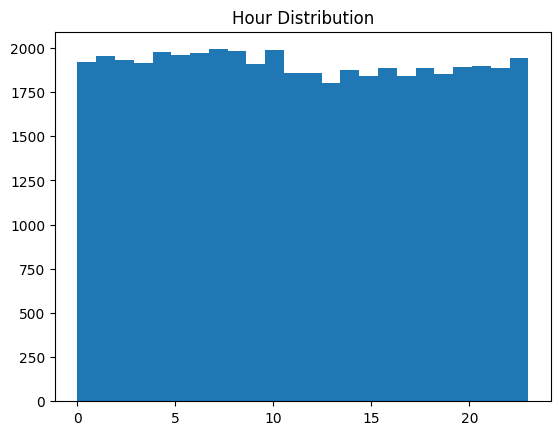

In [ ]:
plt.hist(df["hour"], bins=24)
plt.title("Hour Distribution")
plt.show()

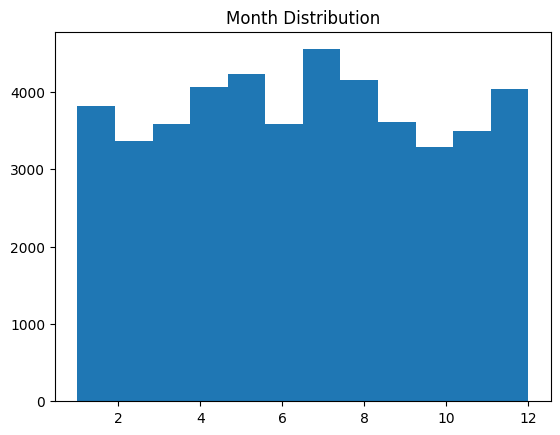

In [ ]:
plt.hist(df["month"], bins=12)
plt.title("Month Distribution")
plt.show()

In [ ]:
df.dtypes

,0
rain_1h,float64
snow_1h,float64
clouds_all,float64
fog_mm,float64
wind_speed_ms,float64
flood_mm,float64
holiday,object
weather_main,object
weather_description,object
traffic_volume,float64


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "holiday",
        "weather_main",
        "weather_description",
        "day_of_week"
    ],
    drop_first=True,
    dtype=int
)

In [ ]:
df.dtypes

,0
rain_1h,float64
snow_1h,float64
clouds_all,float64
fog_mm,float64
wind_speed_ms,float64
...,...
day_of_week_Saturday,int64
day_of_week_Sunday,int64
day_of_week_Thursday,int64
day_of_week_Tuesday,int64


In [ ]:
print(df.shape)
print(df.head())

(45794, 74)
   rain_1h  snow_1h  clouds_all  fog_mm  wind_speed_ms  flood_mm  \
0      0.0      0.0        40.0     0.0           2.30       0.0   
1      0.0      0.0        75.0     0.0           7.45       0.0   
3      0.0      0.0        90.0     0.0           1.93       0.0   
4      0.0      0.0        75.0     0.0           3.56       0.0   
5      0.0      0.0         1.0     0.0           2.41       0.0   

   traffic_volume  hour  month  is_weekend  ...  \
0          5545.0     9     10           0  ...   
1          4516.0    10     10           0  ...   
3          5026.0    12     10           0  ...   
4          4918.0    13     10           0  ...   
5          5181.0    14     10           0  ...   

   weather_description_thunderstorm with light drizzle  \
0                                                  0     
1                                                  0     
3                                                  0     
4                                       

In [ ]:
# Outlier Detection using Boxplots and IQR

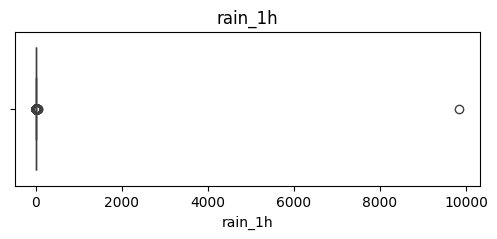

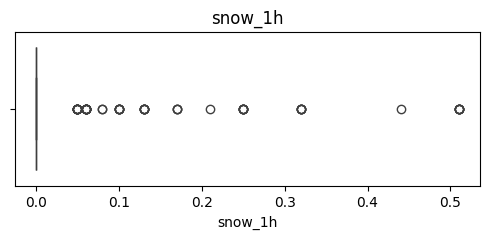

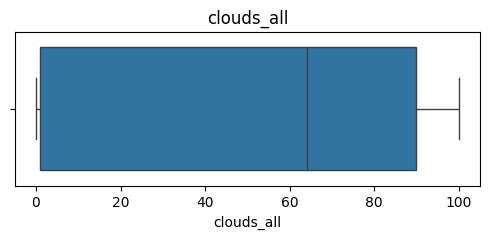

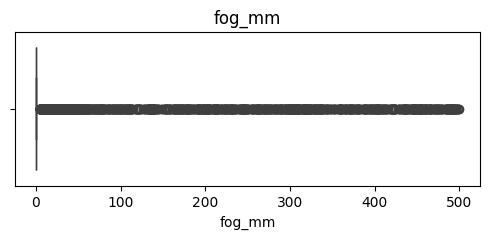

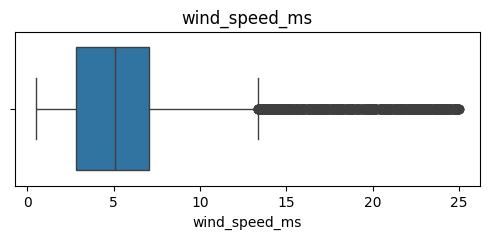

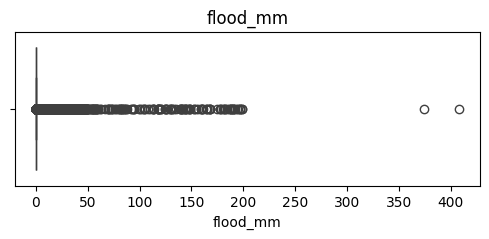

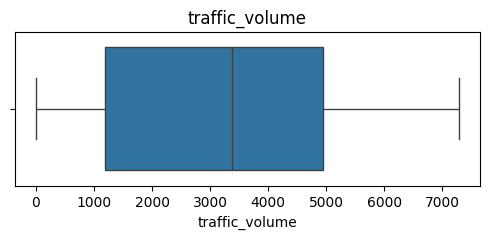

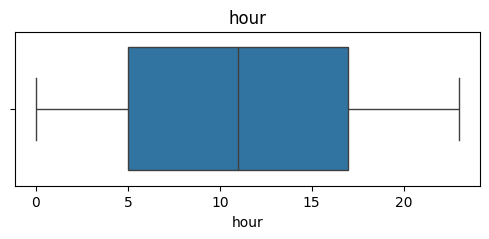

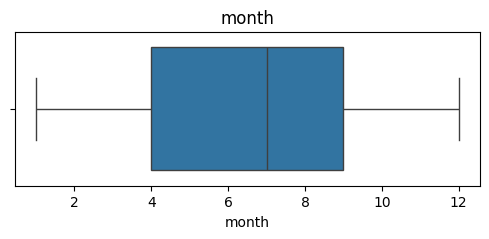

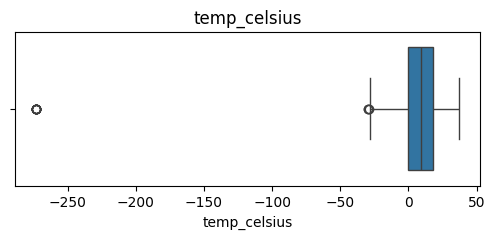

In [ ]:
numeric_cols = [
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "fog_mm",
    "wind_speed_ms",
    "flood_mm",
    "traffic_volume",
    "hour",
    "month",
    "temp_celsius"
]

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
print(df["temp_celsius"].describe())
print("\n")
print(df["rain_1h"].describe())

count    45794.000000
mean         8.112665
std         13.071799
min       -273.150000
25%         -0.550000
50%          9.330000
75%         18.330000
max         36.920000
Name: temp_celsius, dtype: float64


count    45794.000000
mean         0.339396
std         45.951680
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       9831.300000
Name: rain_1h, dtype: float64


In [ ]:
print(df[df["rain_1h"] > 100].shape[0])

1


In [ ]:
numeric_cols = [
    "temp_celsius",
    "wind_speed_ms",
    "clouds_all",
    "fog_mm",
    "flood_mm"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} Outliers")

temp_celsius: 13 Outliers
wind_speed_ms: 1673 Outliers
clouds_all: 0 Outliers
fog_mm: 6517 Outliers
flood_mm: 3128 Outliers


In [ ]:
Q1 = df["temp_celsius"].quantile(0.25)
Q3 = df["temp_celsius"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_temp = df[(df["temp_celsius"] < lower) | (df["temp_celsius"] > upper)]

print(outliers_temp["temp_celsius"])

11898   -273.15
11899   -273.15
11900   -273.15
11901   -273.15
11946   -273.15
11947   -273.15
11948   -273.15
11949   -273.15
11950   -273.15
11951   -273.15
29250    -28.93
29251    -29.53
29252    -29.76
Name: temp_celsius, dtype: float64


In [ ]:
df = df[df["temp_celsius"] != -273.15]

In [ ]:
Q1 = df["rain_1h"].quantile(0.25)
Q3 = df["rain_1h"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["rain_1h"] < lower) | (df["rain_1h"] > upper)]

print(outliers["rain_1h"].describe())

count    3130.000000
mean        4.965585
std       175.726245
min         0.250000
25%         0.250000
50%         0.640000
75%         1.780000
max      9831.300000
Name: rain_1h, dtype: float64


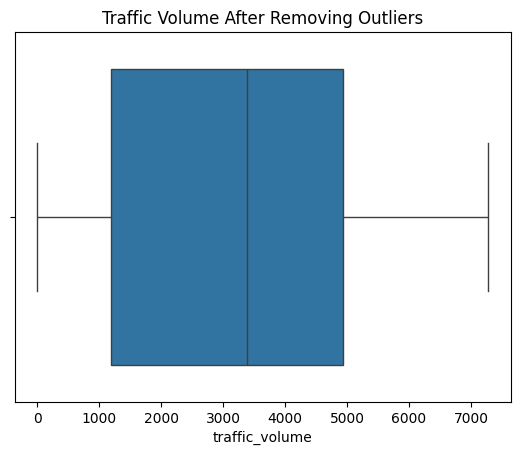

In [ ]:
sns.boxplot(x=df["traffic_volume"])
plt.title("Traffic Volume After Removing Outliers")
plt.show()

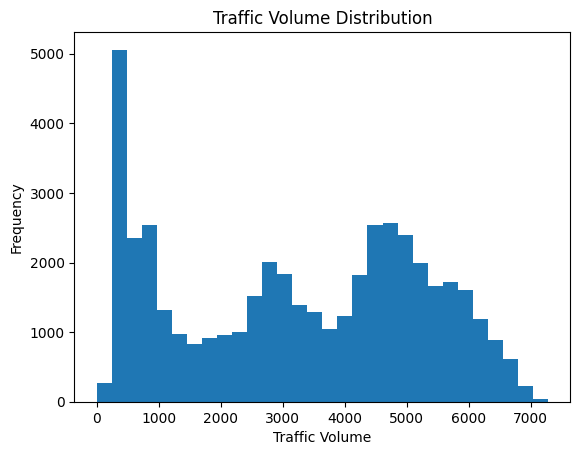

In [ ]:
plt.hist(df["traffic_volume"], bins=30)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['traffic_level'] = pd.qcut(
    df['traffic_volume'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['traffic_level'] = le.fit_transform(df['traffic_level'])

df.head()

,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,traffic_volume,hour,month,is_weekend,...,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,traffic_level
0,0.0,0.0,40.0,0.0,2.30,0.0,5545.0,9,10,0,...,0,0,0,0,0,0,0,1,0,0
1,0.0,0.0,75.0,0.0,7.45,0.0,4516.0,10,10,0,...,0,0,0,0,0,0,0,1,0,2
3,0.0,0.0,90.0,0.0,1.93,0.0,5026.0,12,10,0,...,0,0,0,0,0,0,0,1,0,0
4,0.0,0.0,75.0,0.0,3.56,0.0,4918.0,13,10,0,...,0,0,0,0,0,0,0,1,0,0
5,0.0,0.0,1.0,0.0,2.41,0.0,5181.0,14,10,0,...,0,0,0,0,0,0,0,1,0,0


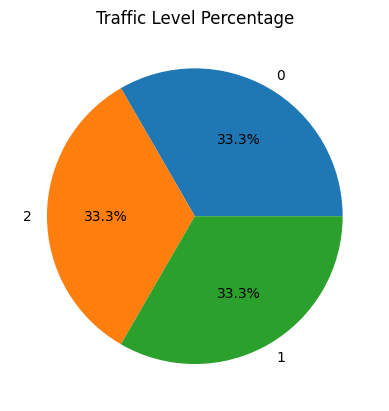

In [ ]:
df["traffic_level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Traffic Level Percentage")
plt.show()

In [ ]:
print(df.shape)
df.head()

(45784, 75)


,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,traffic_volume,hour,month,is_weekend,...,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,traffic_level
0,0.0,0.0,40.0,0.0,2.30,0.0,5545.0,9,10,0,...,0,0,0,0,0,0,0,1,0,0
1,0.0,0.0,75.0,0.0,7.45,0.0,4516.0,10,10,0,...,0,0,0,0,0,0,0,1,0,2
3,0.0,0.0,90.0,0.0,1.93,0.0,5026.0,12,10,0,...,0,0,0,0,0,0,0,1,0,0
4,0.0,0.0,75.0,0.0,3.56,0.0,4918.0,13,10,0,...,0,0,0,0,0,0,0,1,0,0
5,0.0,0.0,1.0,0.0,2.41,0.0,5181.0,14,10,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
X = df.drop(columns=["traffic_volume"])
y = df["traffic_volume"]

In [ ]:
print(X.shape)
print(y.shape)

(45784, 74)
(45784,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36627, 74)
(9157, 74)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (36627, 74)
X_test : (9157, 74)
y_train: (36627,)
y_test : (9157,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

Train RMSE: 1557.3087
Test RMSE: 4003.8598
Train MAE: 1310.5281
Test MAE: 1358.1109
Train R²: 0.3852
Test R²: -3.0468


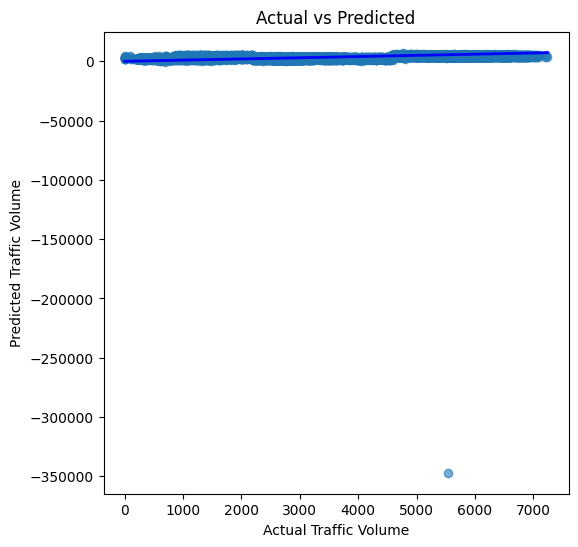

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='blue', linewidth=2)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE : {ridge_mae:.4f}")
print(f"R²  : {ridge_r2:.4f}")

RMSE: 4003.4166
MAE : 1358.1134
R²  : -3.0460


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE : {lasso_mae:.4f}")
print(f"R²  : {lasso_r2:.4f}")

RMSE: 3949.6367
MAE : 1357.5368
R²  : -2.9380
